In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Hugging Face

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face


In [ ]:
!pip install -q transformers datasets torchvision pycocotools
!pip install -q accelerate evaluate

In [ ]:
!pip install wandb

In [2]:
from huggingface_hub import login
from google.colab import userdata
token = userdata.get('Nyi_token')
login(token=token)

In [3]:
import os
os.environ["WANDB_DIR"] = "/content/"

In [4]:
import os
os.environ["WANDB_MODE"] = "online"
os.environ["HF_WANDB_LOG_ARTIFACTS"] = "True" # but not worked

In [5]:
import wandb
wandb.login(key="")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nyinyimyo (nyinyimyo-khon-kaen-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import json
from transformers import AutoImageProcessor, RfDetrForObjectDetection, TrainingArguments, Trainer
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import torchvision.transforms as T

In [7]:
class CircuitDetDataset(Dataset):
    def __init__(self, images_dir, annotation_file, transforms=None):
        self.images_dir = images_dir
        self.transforms = transforms

        with open(annotation_file) as f:
            coco = json.load(f)

        self.image_id_to_filename = {img["id"]: img["file_name"] for img in coco["images"]}
        self.id_to_annotations = {}
        for ann in coco["annotations"]:
            img_id = ann["image_id"]
            self.id_to_annotations.setdefault(img_id, []).append(ann)
        self.img_ids = list(self.image_id_to_filename.keys())
        self.categories = {cat["id"]: cat["name"] for cat in coco["categories"]}

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_path = os.path.join(self.images_dir, self.image_id_to_filename[img_id])
        image = Image.open(img_path).convert("RGB")

        annotations = self.id_to_annotations.get(img_id, [])
        target = {
            "image_id": img_id,
            "annotations": annotations
        }

        if self.transforms:
            image = self.transforms(image)

        return image, target

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained("stevenbucaille/rf-detr-medium")
model = RfDetrForObjectDetection.from_pretrained("stevenbucaille/rf-detr-medium", device_map=device)

In [9]:
class RFDETRProcessedDataset(Dataset):
    def __init__(self, base_dataset, processor):
        self.base_dataset = base_dataset
        self.processor = processor

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, target = self.base_dataset[idx]

        # Wrap annotations dict for a single image inside a list
        encoding = self.processor(
            images=image,
            annotations=[target],  # wrap in list
            return_tensors="pt"
        )

        encoding["pixel_values"] = encoding["pixel_values"].squeeze(0)
        encoding["labels"] = encoding["labels"][0]
        return encoding

In [10]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/CircuitRecognitioncoco/train")
count_images("datasets/CircuitRecognitioncoco/valid")

Total images: 2652
Total images: 400


In [11]:
# Check train annotations
with open("datasets/CircuitRecognitioncoco/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/CircuitRecognitioncoco/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 2652
Train annotations: 14749
Categories: [{'id': 0, 'name': 'Predict-circuit-parameters', 'supercategory': 'none'}, {'id': 1, 'name': 'acv', 'supercategory': 'Predict-circuit-parameters'}, {'id': 2, 'name': 'c', 'supercategory': 'Predict-circuit-parameters'}, {'id': 3, 'name': 'i', 'supercategory': 'Predict-circuit-parameters'}, {'id': 4, 'name': 'l', 'supercategory': 'Predict-circuit-parameters'}, {'id': 5, 'name': 'r', 'supercategory': 'Predict-circuit-parameters'}, {'id': 6, 'name': 'v', 'supercategory': 'Predict-circuit-parameters'}]

Valid images: 400
Valid annotations: 2208


In [12]:
train_dataset = CircuitDetDataset(
    images_dir="datasets/CircuitRecognitioncoco/train",
    annotation_file="datasets/CircuitRecognitioncoco/train/_annotations.coco.json"
)

valid_dataset = CircuitDetDataset(
    images_dir="datasets/CircuitRecognitioncoco/valid",
    annotation_file="datasets/CircuitRecognitioncoco/valid/_annotations.coco.json"
)

train_processed = RFDETRProcessedDataset(train_dataset, processor)
valid_processed = RFDETRProcessedDataset(valid_dataset, processor)

In [13]:
class RFDETRDataCollator:
    def __call__(self, features):
        pixel_values = torch.stack([f["pixel_values"] for f in features])
        labels = [f["labels"] for f in features]
        return {"pixel_values": pixel_values, "labels": labels}

In [14]:
print(model.config.backbone_config.image_size)
print(model.config.backbone_config.patch_size)
print(model.config.backbone_config.num_windows)

576
16
2


In [15]:
training_args = TrainingArguments(
    output_dir="./detrresults/rfdetr-circuit",

    per_device_train_batch_size=8,       # Adjusted to fit typical Colab GPU memory
    per_device_eval_batch_size=8,
    dataloader_num_workers=2,
    learning_rate=5e-5,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,                   # Keep only 1 checkpoint

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",    # DETR default metric (loss)
    greater_is_better=False,              # Lower loss is better

    report_to="wandb",                     # none if no wandb/tensorboard/mlflow
    logging_steps=20,
    run_name="rfdetr-circuit",

    num_train_epochs=10,
)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_processed,
    eval_dataset=valid_processed,
    data_collator=RFDETRDataCollator(),
)

In [ ]:
torch.cuda.empty_cache()

In [ ]:
trainer.train()

In [ ]:
wandb.finish()

eval/loss,█▇▁▁▁▃▄▄▄▄
eval/runtime,▂█▆▆▅▁▂▄▆▅
eval/samples_per_second,▇▁▃▃▄█▆▅▃▄
eval/steps_per_second,▇▁▃▃▄█▆▅▃▄
train/epoch,▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇██
train/global_step,▁▁▁▁▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▂▂▃▆▁▂▂▂▄▃▃▂▂▃▂▁▂▅▂▂▁▂▆▁▁▂▂▁▂▁▂▂▂█▁▃▃▅▁▁
train/learning_rate,██████▇▇▇▇▆▆▆▆▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
train/loss,█▆▅▅▄▄▄▃▃▃▄▃▃▃▃▃▃▃▃▃▂▃▃▃▂▃▃▂▂▂▂▃▂▂▁▂▂▁▁▁
eval/loss,14.99017
eval/runtime,17.8513


In [ ]:
# Tracking run with wandb version 0.27.2
# Run data is saved locally in /content/wandb/run-20260623_125317-alj1l475
# Syncing run rfdetr-circuit to Weights & Biases (docs)
# View project at https://wandb.ai/nyinyimyo-khon-kaen-university/huggingface
# View run at https://wandb.ai/nyinyimyo-khon-kaen-university/huggingface/runs/alj1l475
#  [3320/3320 1:37:00, Epoch 10/10]
# Epoch	Training Loss	Validation Loss
# 1	6.052910	16.167809
# 2	5.857528	15.686704
# 3	5.570549	13.929397
# 4	5.033194	13.858993
# 5	4.963235	13.962097
# 6	4.483880	14.557498
# 7	4.454869	14.745649
# 8	4.288771	14.716223
# 9	3.931686	14.861948
# 10	3.812155	14.990172
# Writing model shards: 100%
#  1/1 [00:00<00:00,  1.88it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  2.45it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  1.70it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  2.12it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  2.24it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  2.25it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  2.18it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  1.78it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  1.74it/s]
# Writing model shards: 100%
#  1/1 [00:00<00:00,  2.21it/s]
# TrainOutput(global_step=3320, training_loss=4.881405494873782, metrics={'train_runtime': 5827.3043, 'train_samples_per_second': 4.551, 'train_steps_per_second': 0.57, 'total_flos': 5.174710905984123e+18, 'train_loss': 4.881405494873782, 'epoch': 10.0})

In [ ]:
best_model_path = "./detrresults/rfdetr-circuit"

with wandb.init(project="huggingface", name="rfdetr-circuit-best-model") as run:
    artifact = wandb.Artifact(
        name="rfdetr-circuit-best-model",
        type="model",
        description="Best RF_DETR model selected by eval_loss"
    )
    artifact.add_dir(best_model_path)

    run.log_artifact(artifact)
    run.finish()
print("Best model checkpoint successfully uploaded to W&B Artifacts!")

wandb: Adding directory to artifact (detrresults/rfdetr-circuit)... Done. 2.3s


Best model checkpoint successfully uploaded to W&B Artifacts!


In [ ]:
import wandb
run = wandb.init(entity="nyinyimyo-khon-kaen-university", project="huggingface")
artifact = run.use_artifact("nyinyimyo-khon-kaen-university/huggingface/rfdetr-circuit-best-model:v0", type="model")
artifact_dir = artifact.download()

In [ ]:
import wandb
run = wandb.init(project="artifact-registry-example")
artifact = run.use_artifact("nyinyimyo-khon-kaen-university-org/wandb-registry-rfdetr-circuit-best/Best models:v0", type="model")
artifact_dir = artifact.download()

wandb: Downloading large artifact 'Best models:v0', 386.04MB. 7 files...
wandb:   7 of 7 files downloaded.  
Done. 00:00:03.9 (98.1MB/s)


In [ ]:
from pathlib import Path
Path(artifact_dir) / "checkpoint-1328"

PosixPath('/content/gdrive/.shortcut-targets-by-id/1OAwQPoxfnPPp90tlzRE1fTmfB377ksLA/Hugging Face/artifacts/rfdetr-circuit-best-model:v0/checkpoint-1328')

In [ ]:
register_model = RfDetrForObjectDetection.from_pretrained(Path(artifact_dir) / "checkpoint-1328")

In [ ]:
wandb.finish()

In [17]:
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def run_per_class_eval(model, val_dataset, processor, annotation_file, class_names, device="cuda", threshold=0.1):
    # Load COCO ground truth
    coco_gt = COCO(annotation_file)

    # Build a mapping from category name to category ID (COCO IDs)
    cats = coco_gt.loadCats(coco_gt.getCatIds())
    name_to_catid = {cat["name"]: cat["id"] for cat in cats}

    # Map model class index (based on class_names list) to COCO category ID
    class_idx_to_catid = {}
    for idx, cname in enumerate(class_names):
        if cname in name_to_catid:
            class_idx_to_catid[idx] = name_to_catid[cname]
        else:
            class_idx_to_catid[idx] = None

    # Inverse map: category ID -> class index for evaluation printing
    catid_to_class_idx = {v: k for k, v in class_idx_to_catid.items() if v is not None}

    model.eval()
    model.to(device)

    results = []
    for idx, item in enumerate(tqdm(val_dataset, desc="Evaluating")):
        if hasattr(val_dataset, "base_dataset"):
            pil_img, labels = val_dataset.base_dataset[idx]
            pixel_values = processor(images=pil_img, return_tensors="pt").pixel_values.to(device)
            height, width = pil_img.height, pil_img.width
            image_id = labels.get("image_id", idx) if isinstance(labels, dict) else idx
        else:
            pixel_values = item["pixel_values"].unsqueeze(0).to(device)
            labels = item["labels"]
            height, width = labels["size"].tolist()
            image_id = labels["image_id"].item()

        with torch.no_grad():
            outputs = model(pixel_values)

        processed = processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=torch.tensor([[height, width]], device=device),
            threshold=threshold
        )[0]

        for score, label, box in zip(processed["scores"], processed["labels"], processed["boxes"]):
            class_idx = label.item()
            category_id = class_idx_to_catid.get(class_idx, None)
            if category_id is None:
                continue

            x_min, y_min, x_max, y_max = box.tolist()
            bbox = [float(x_min), float(y_min), float(x_max - x_min), float(y_max - y_min)]

            results.append({
                "image_id": int(image_id),
                "category_id": int(category_id),
                "bbox": bbox,
                "score": float(score.item())
            })

    if len(results) == 0:
        print("⚠️ No predictions found above threshold. Try lowering threshold or check preprocessing.")
        return

    pred_file = "datasets/rtdetr_predictions.json"
    with open(pred_file, "w") as f:
        json.dump(results, f)

    with open(annotation_file, "r") as f:
        coco_data = json.load(f)
    coco_data.setdefault("info", {"description": "patched"})
    coco_data.setdefault("licenses", [{"id": 0, "name": "none", "url": ""}])
    patched_gt_file = "datasets/rtdetr_patched_gt.json"
    with open(patched_gt_file, "w") as f:
        json.dump(coco_data, f)

    coco_gt_eval = COCO(patched_gt_file)
    coco_dt_eval = coco_gt_eval.loadRes(pred_file)

    coco_eval = COCOeval(coco_gt_eval, coco_dt_eval, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    precisions = coco_eval.eval['precision']
    recalls = coco_eval.eval['recall']

    print("\n📊 Per-class Evaluation (IoU=0.50:0.95):")
    print(f"{'Class':<5} {'Name':<20} {'Precision':>9} {'Recall':>9} {'F1 Score':>9}")
    print("-" * 55)

    per_class_p, per_class_r, per_class_f1 = [], [], []

    for cat_id in coco_eval.params.catIds:
        if cat_id not in catid_to_class_idx:
            continue

        i = catid_to_class_idx[cat_id]
        cat_idx = coco_eval.params.catIds.index(cat_id)

        precision = precisions[:, :, cat_idx, 0, 0]
        recall = recalls[:, cat_idx, 0, 0]

        valid_p = precision[precision > -1]
        valid_r = recall[recall > -1]

        p = np.mean(valid_p) if valid_p.size > 0 else 0.0
        r = np.mean(valid_r) if valid_r.size > 0 else 0.0
        f1 = 2 * p * r / (p + r + 1e-8) if (p + r) > 0 else 0.0

        per_class_p.append(p)
        per_class_r.append(r)
        per_class_f1.append(f1)

        print(f"{i:<5} {class_names[i]:<20} {p:9.4f} {r:9.4f} {f1:9.4f}")

    print("\n🔍 Overall Average:")
    print(f"Precision: {np.mean(per_class_p):.4f}")
    print(f"Recall:    {np.mean(per_class_r):.4f}")
    print(f"F1 Score:  {np.mean(per_class_f1):.4f}")

    return {
        "Precision": np.mean(per_class_p),
        "Recall": np.mean(per_class_r),
        "F1 Score": np.mean(per_class_f1)
    }

In [ ]:
model = RfDetrForObjectDetection.from_pretrained("detrresults/rfdetr-circuit/checkpoint-1328")

In [ ]:
metrics = run_per_class_eval(
    model=model,
    val_dataset=valid_processed,
    processor=processor,
    annotation_file="datasets/CircuitRecognitioncoco/valid/_annotations.coco.json",
    device="cuda",
    class_names = ['Predict-circuit-parameters', 'acv', 'c', 'i', 'l', 'r', 'v']
)

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!


Evaluating: 100%|██████████| 400/400 [03:27<00:00,  1.92it/s]


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.66s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.94s).
Accumulating evaluation results...
DONE (t=0.39s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.589
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.931
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.655
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.327
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.592
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.400
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.481
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.678
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [ ]:
with wandb.init(project="huggingface", name="rfdetr-circuit-Evaluation") as run:
    columns = ["Model", "Precision", "Recall", "F1"]
    table = wandb.Table(columns=columns)
    table.add_data("RF_DETR", metrics["Precision"], metrics["Recall"], metrics["F1 Score"])
    run.log({"Average Metrics:": table})

    run.log(metrics)
    run.finish()
print("Overall Average Metrics successfully uploaded to W&B!")

F1 Score,▁
Precision,▁
Recall,▁
F1 Score,0.38665
Precision,0.3641
Recall,0.41253


Overall Average Metrics successfully uploaded to W&B!


In [19]:
# Registered model eval

In [ ]:
run_per_class_eval(
    model=register_model,
    val_dataset=valid_processed,
    processor=processor,
    annotation_file="datasets/CircuitRecognitioncoco/valid/_annotations.coco.json",
    device="cuda",
    class_names = ['Predict-circuit-parameters', 'acv', 'c', 'i', 'l', 'r', 'v']
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


Evaluating: 100%|██████████| 400/400 [00:29<00:00, 13.71it/s]


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.08s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.87s).
Accumulating evaluation results...
DONE (t=0.36s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.589
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.931
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.655
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.327
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.592
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.400
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.481
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.678
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

{'Precision': np.float64(0.36410097326280033),
 'Recall': np.float64(0.4125314546893861),
 'F1 Score': np.float64(0.3866522100879269)}

In [20]:
def plot_rfdetr_predictions(model, dataset, processor, class_names, device="cuda", num_images=24):
    model.eval().to(device)
    cols = 4
    rows = math.ceil(num_images / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), dpi=150)
    axes = axes.flatten()

    # Define distinct BGR colors for each clas
    colors = {
        0: (0, 0, 0),          # background - black
        1: (0, 255, 160),      # yellow
        2: (0, 255, 0),        # green
        3: (255, 0, 0),        # blue
        4: (255, 255, 0),      # cyan
        5: (0, 0, 255),        # red
        6: (255, 0, 255),      # magenta
    }
    class_colors = {i: colors[i % len(colors)] for i in range(len(class_names))}

    # Select random indices from dataset
    all_indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    for i, idx in enumerate(all_indices):
        if hasattr(dataset, 'base_dataset'):
            pil_img, _ = dataset.base_dataset[idx]
            orig_img = np.array(pil_img.convert("RGB"))
            img_tensor = processor(images=pil_img, return_tensors="pt").pixel_values.to(device)
        else:
            print("Base dataset not found. Skipping.")
            continue

        with torch.no_grad():
            outputs = model(img_tensor)

        height, width = orig_img.shape[:2]
        results = processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=torch.tensor([[height, width]], device=device),
            threshold=0.5
        )[0]

        draw_img = cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR)
        height2, width2, channels = draw_img.shape
        if width2 > 800:
            fontsize = 3
            fontthickness = 3
            linethickness = 10
        else:
            fontsize = 1
            fontthickness = 2
            linethickness = 3

        for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
            x1, y1, x2, y2 = map(int, box.tolist())
            class_id = label.item()
            if class_id >= len(class_names):
                continue  # skip invalid class id
            color = class_colors.get(class_id, (255, 255, 255))
            label_text = f"{class_names[class_id]}: {score:.2f}"
            cv2.rectangle(draw_img, (x1, y1), (x2, y2), color, linethickness)
            cv2.putText(draw_img, label_text, (x1, max(y1 - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, fontsize, color, fontthickness, cv2.LINE_AA)

        draw_img = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(draw_img, interpolation='none')
        axes[i].axis("off")
        axes[i].set_title(f"Image {i + 1}")

    for i in range(num_images, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

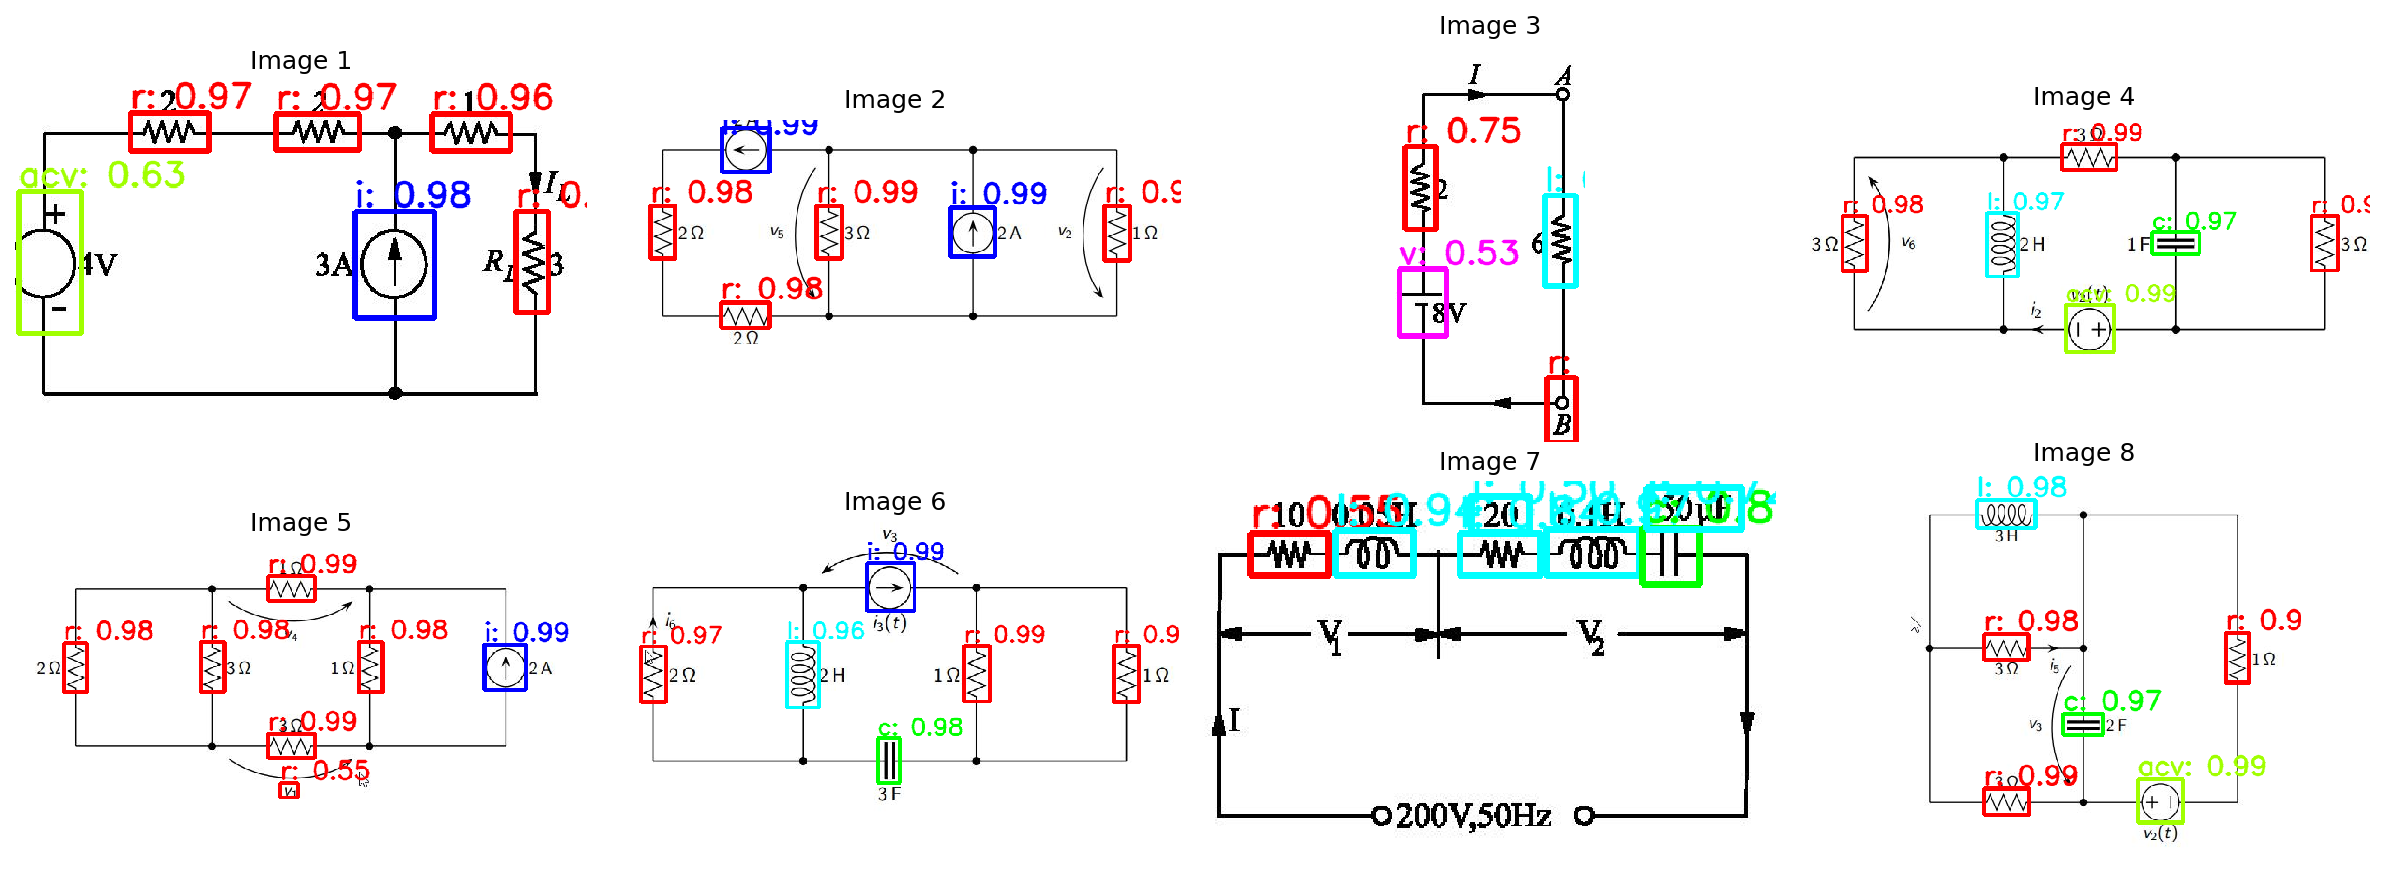

In [ ]:
class_names = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

plot_rfdetr_predictions(
    model=model,
    dataset=valid_processed,
    processor=processor,
    class_names=class_names,
    device="cuda",
    num_images=8)

In [21]:
# Inference run Wandb

In [22]:
def plot_rfdetr_predictions(model, dataset, processor, class_names, device="cuda", num_images=24):
    model.eval().to(device)
    cols = 4
    rows = math.ceil(num_images / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), dpi=150)
    axes = axes.flatten()

    # Define distinct BGR colors for each clas
    colors = {
        0: (0, 0, 0),          # background - black
        1: (0, 255, 160),      # yellow
        2: (0, 255, 0),        # green
        3: (255, 0, 0),        # blue
        4: (255, 255, 0),      # cyan
        5: (0, 0, 255),        # red
        6: (255, 0, 255),      # magenta
    }
    class_colors = {i: colors[i % len(colors)] for i in range(len(class_names))}

    # Select random indices from dataset
    all_indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    with wandb.init(project="huggingface", name="rfdetr-circuit-Inference") as run:

        for i, idx in enumerate(all_indices):
            if hasattr(dataset, 'base_dataset'):
                pil_img, _ = dataset.base_dataset[idx]
                orig_img = np.array(pil_img.convert("RGB"))
                img_tensor = processor(images=pil_img, return_tensors="pt").pixel_values.to(device)
            else:
                print("Base dataset not found. Skipping.")
                continue

            with torch.no_grad():
                outputs = model(img_tensor)

            height, width = orig_img.shape[:2]
            results = processor.post_process_object_detection(
                outputs=outputs,
                target_sizes=torch.tensor([[height, width]], device=device),
                threshold=0.5
            )[0]

            draw_img = cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR)
            height2, width2, channels = draw_img.shape
            if width2 > 800:
                fontsize = 3
                fontthickness = 3
                linethickness = 10
            else:
                fontsize = 1
                fontthickness = 2
                linethickness = 3

            for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
                x1, y1, x2, y2 = map(int, box.tolist())
                class_id = label.item()
                if class_id >= len(class_names):
                    continue  # skip invalid class id
                color = class_colors.get(class_id, (255, 255, 255))
                label_text = f"{class_names[class_id]}: {score:.2f}"
                cv2.rectangle(draw_img, (x1, y1), (x2, y2), color, linethickness)
                cv2.putText(draw_img, label_text, (x1, max(y1 - 5, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, fontsize, color, fontthickness, cv2.LINE_AA)

            draw_img = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(draw_img, interpolation='none')
            axes[i].axis("off")
            axes[i].set_title(f"Image {i + 1}")

        for i in range(num_images, len(axes)):
            axes[i].axis("off")

        run.log({"Inference": wandb.Image(plt, caption="Results Image")})
        run.finish()

    plt.tight_layout()
    plt.show()

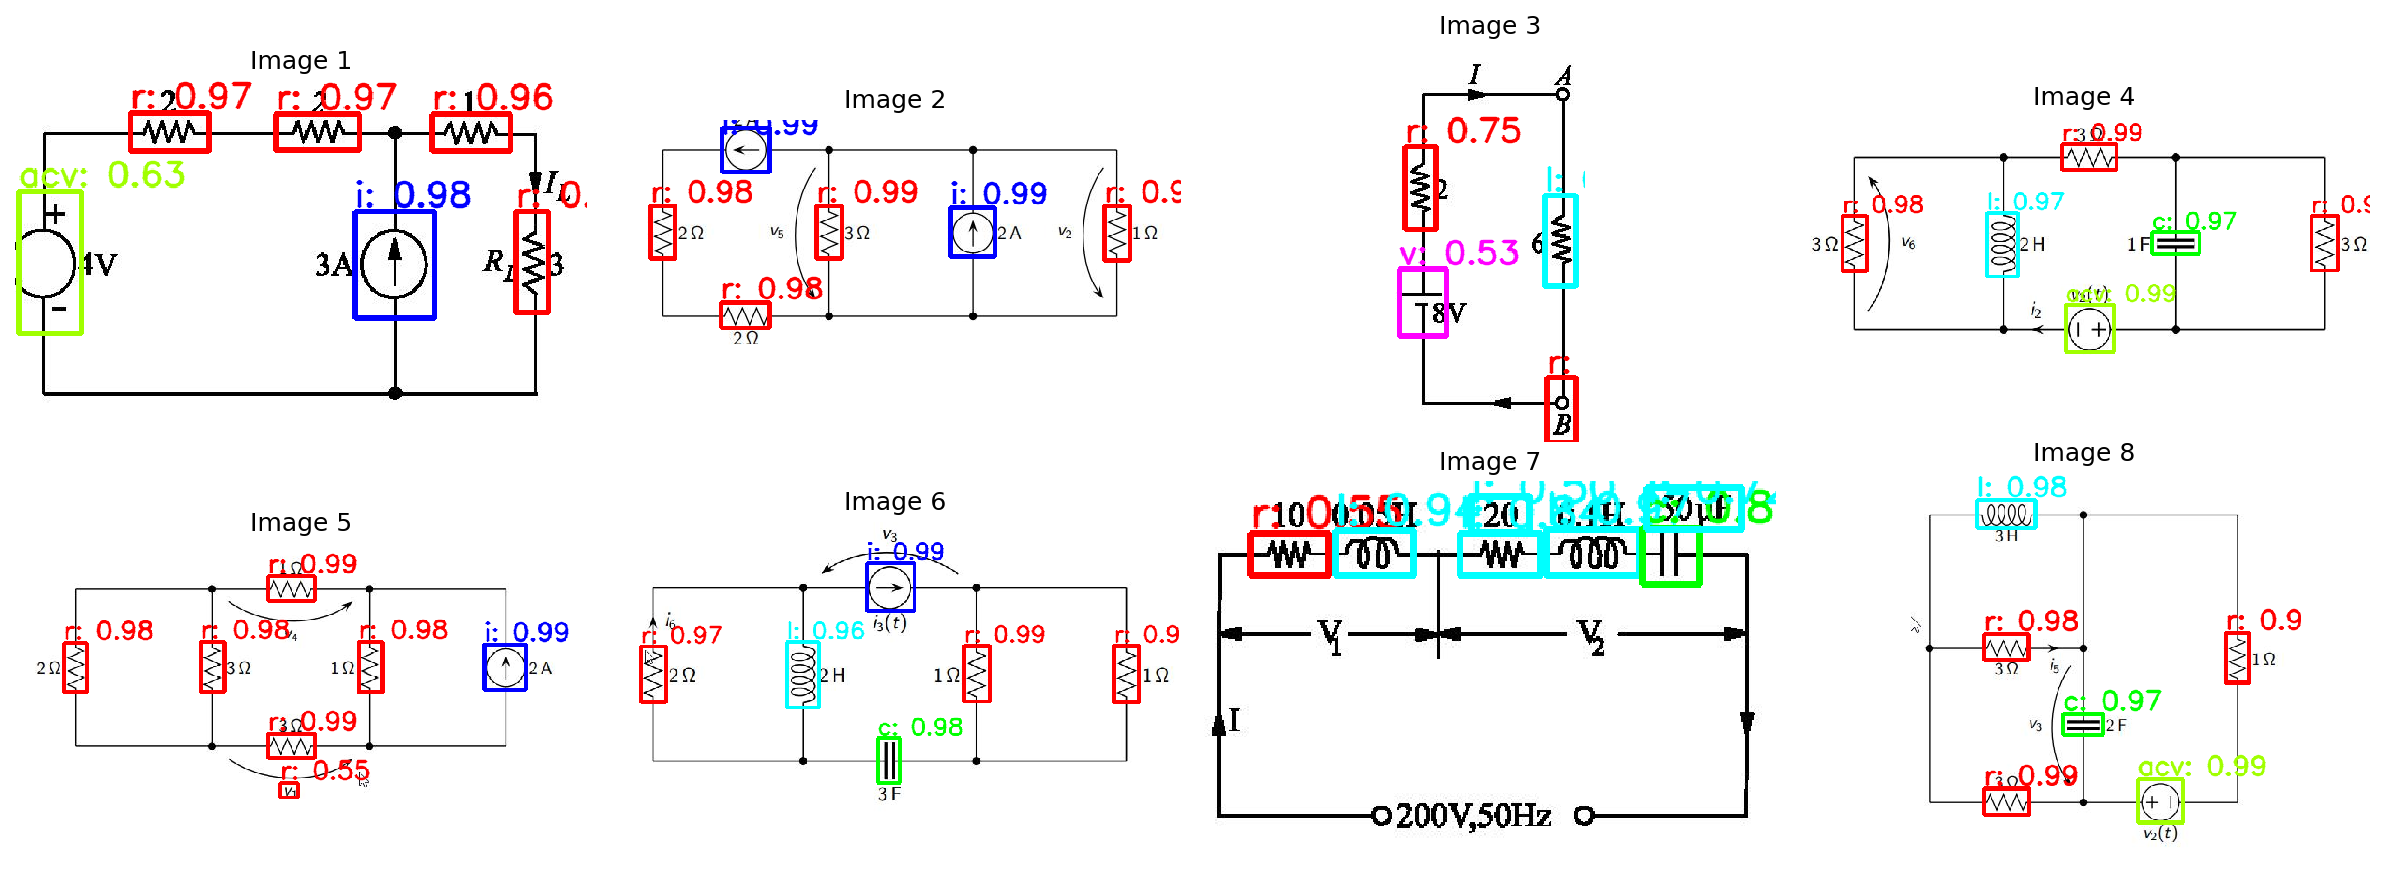

In [ ]:
class_names = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

plot_rfdetr_predictions(
    model=model,
    dataset=valid_processed,
    processor=processor,
    class_names=class_names,
    device="cuda",
    num_images=8)

In [31]:
def plot_rfdetr_predictions(model, dataset, processor, class_names, device="cuda", num_images=24):
    model.eval().to(device)

    # Map class_ids to names for the W&B interactive UI legend
    class_id_to_label = {i: name for i, name in enumerate(class_names)}

    # Select random indices from dataset
    all_indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    with wandb.init(project="huggingface", name="rfdetr-circuit-Visual-Overlays-Eval") as run:

        columns = ["Image ID", "Interactive Detection View"]
        table = wandb.Table(columns=columns)

        for i, idx in enumerate(all_indices):
            # 1. Fetch image and target annotations from dataset
            if hasattr(dataset, 'base_dataset'):
                pil_img, target = dataset.base_dataset[idx]
                orig_img = np.array(pil_img.convert("RGB"))
                img_tensor = processor(images=pil_img, return_tensors="pt").pixel_values.to(device)
            else:
                print("Base dataset not found. Skipping.")
                continue

            # 2. Get Model Predictions
            with torch.no_grad():
                outputs = model(img_tensor)

            height, width = orig_img.shape[:2]
            results = processor.post_process_object_detection(
                outputs=outputs,
                target_sizes=torch.tensor([[height, width]], device=device),
                threshold=0.5
            )[0]

            # 3. Parse PREDICTION Bounding Boxes
            pred_box_data = []
            for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
                x1, y1, x2, y2 = box.tolist()
                class_id = int(label.item())

                if class_id >= len(class_names):
                    continue

                pred_box_data.append({
                    "position": {
                        "minX": x1,
                        "minY": y1,
                        "maxX": x2,
                        "maxY": y2
                    },
                    "class_id": class_id,
                    "scores": {
                        "confidence": float(score.item())
                    },
                    "domain": "pixel"
                })

            # 4. Parse GROUND TRUTH Bounding Boxes
            gt_box_data = []

            if "annotations" in target:
                for annot in target["annotations"]:
                    class_id = int(annot["category_id"])
                    bbox = annot["bbox"]

                    x_min, y_min, w, h = bbox
                    x1 = int(x_min)
                    y1 = int(y_min)
                    x2 = int(x_min + w)
                    y2 = int(y_min + h)

                    gt_box_data.append({
                        "position": {
                            "minX": x1,
                            "minY": y1,
                            "maxX": x2,
                            "maxY": y2
                        },
                        "class_id": class_id,
                        "scores": {
                            "confidence": 1.0
                        },
                        "domain": "pixel"
                    })

            # 5. Create Interactive W&B Image with TWO overlay layers
            rich_image = wandb.Image(
                orig_img,
                boxes={
                    "predictions": {
                        "box_data": pred_box_data,
                        "class_labels": class_id_to_label
                    },
                    "ground_truth": {
                        "box_data": gt_box_data,
                        "class_labels": class_id_to_label
                    }
                }
            )

            # Append the data to table rows
            table.add_data(f"sample_{idx}", rich_image)
            print(f"Added interactive predictions + GT data for index: {idx}")

        # Sync Table to W&B dashboard
        run.log({"Visual Evaluation Table": table})
        run.finish()
        print("✅ Run inference completed and sync finished successfully!")

In [32]:
# print("HF DATA SAMPLE:", valid_processed.base_dataset[0])

In [33]:
class_names = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

plot_rfdetr_predictions(
    model=model,
    dataset=valid_processed,
    processor=processor,
    class_names=class_names,
    device="cuda",
    num_images=8)

Added interactive predictions + GT data for index: 16
Added interactive predictions + GT data for index: 15
Added interactive predictions + GT data for index: 47
Added interactive predictions + GT data for index: 111
Added interactive predictions + GT data for index: 119
Added interactive predictions + GT data for index: 258
Added interactive predictions + GT data for index: 308
Added interactive predictions + GT data for index: 13


✅ Run inference completed and sync finished successfully!


In [ ]:
!pip install onnx onnxscript
!pip uninstall -y onnxruntime onnxruntime-gpu ort-nightly ort-gpu-nightly
!pip install --no-cache-dir onnxruntime-gpu==1.22.0

In [ ]:
!pip list | grep onnx

onnx                                     1.22.0
onnx-ir                                  0.2.1
onnxruntime-gpu                          1.22.0
onnxscript                               0.7.0


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [ ]:
model = model.to(device)
dummy_input = torch.randn(1, 3, 576, 576).to(device)

In [ ]:
model.config._attn_implementation = "eager"

In [ ]:
onnx_model_path = "detrresults/rfdetr_circuit.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=19,
    input_names=["input"],
    output_names=["boxes"],
    dynamic_axes={
        "input": {0: "batch_size", 2: "height", 3: "width"},
        "boxes": {0: "num_boxes"},
    },
    do_constant_folding=True,
)
print(f"ONNX export {onnx_model_path} completed successfully!")

/tmp/ipykernel_35681/667033005.py:2: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `RfDetrForObjectDetection([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `RfDetrForObjectDetection([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:487: UserWarning: # The axis name: width will not be used, since it shares the same shape constraints with another axis: height.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


ONNX export detrresults/rfdetr_circuit.onnx completed successfully!


In [ ]:
import onnxruntime
import numpy as np
import cv2
import torch
import os
import random

# Load image and preprocess
img_path = "datasets/CircuitRecognitioncoco/valid/autockt_-83_png.rf.528f173e9fc24d0099f7645860356c33.jpg"

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (576, 576))
img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("detrresults/rfdetr_circuit.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 300, 91), (1, 300, 4), (1, 300, 4), (1, 300, 256), (4, 1, 300, 256), (1, 1, 300, 4), (1, 300, 91), (1, 300, 4), (1, 256, 36, 36)]


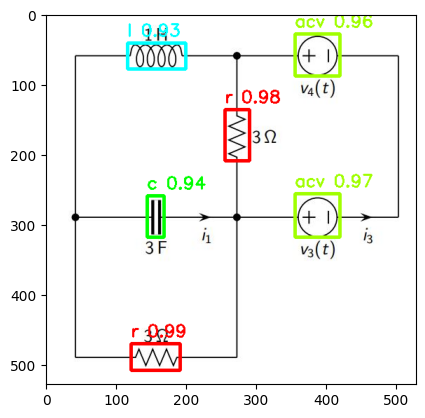

In [ ]:
import cv2
import numpy as np
import os
import random
from matplotlib import pyplot as plt

# Class labels
CLASS_LABELS = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

colors = {
        0: (0, 0, 0),          # background - black
        1: (0, 255, 160),      # yellow
        2: (0, 255, 0),        # green
        3: (255, 0, 0),        # blue
        4: (255, 255, 0),      # cyan
        5: (0, 0, 255),        # red
        6: (255, 0, 255),      # magenta
}

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -50, 50)))

def visualize_results(img_orig, outputs, threshold=0.8):
    h, w = img_orig.shape[:2]
    annotated_img = img_orig.copy()

    final_cls_logits = outputs[0][0]   # Shape: (100, 3)
    final_boxes = outputs[1][0]        # Shape: (100, 4) -> [cx, cy, bw, bh] normalized

    # Get probabilities for all 100 queries
    probs = softmax(final_cls_logits)

    # In YOLOS/DETR, the last column is usually the "Background" class
    scores = np.max(probs[:, :-1], axis=1)
    labels = np.argmax(probs[:, :-1], axis=1)

    keep_indices = np.where(scores > threshold)[0]

    for idx in keep_indices:
        score = scores[idx]
        label = labels[idx]
        labeltext = CLASS_LABELS[label]
        color = colors[label]

        if label == 0: continue

        # YOLOS Box Decoding: [center_x, center_y, width, height] -> [x1, y1, x2, y2]
        cx, cy, bw, bh = final_boxes[idx]

        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)

        # Clip coordinates to image size
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        # Draw the bounding box and text
        cv2.rectangle(annotated_img, (x1, y1), (x2, y2), color, 3)
        cv2.putText(annotated_img, f"{labeltext} {score:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    return annotated_img

# EXECUTE
result_viz = visualize_results(img, outputs, threshold=0.5)
plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
plt.show()

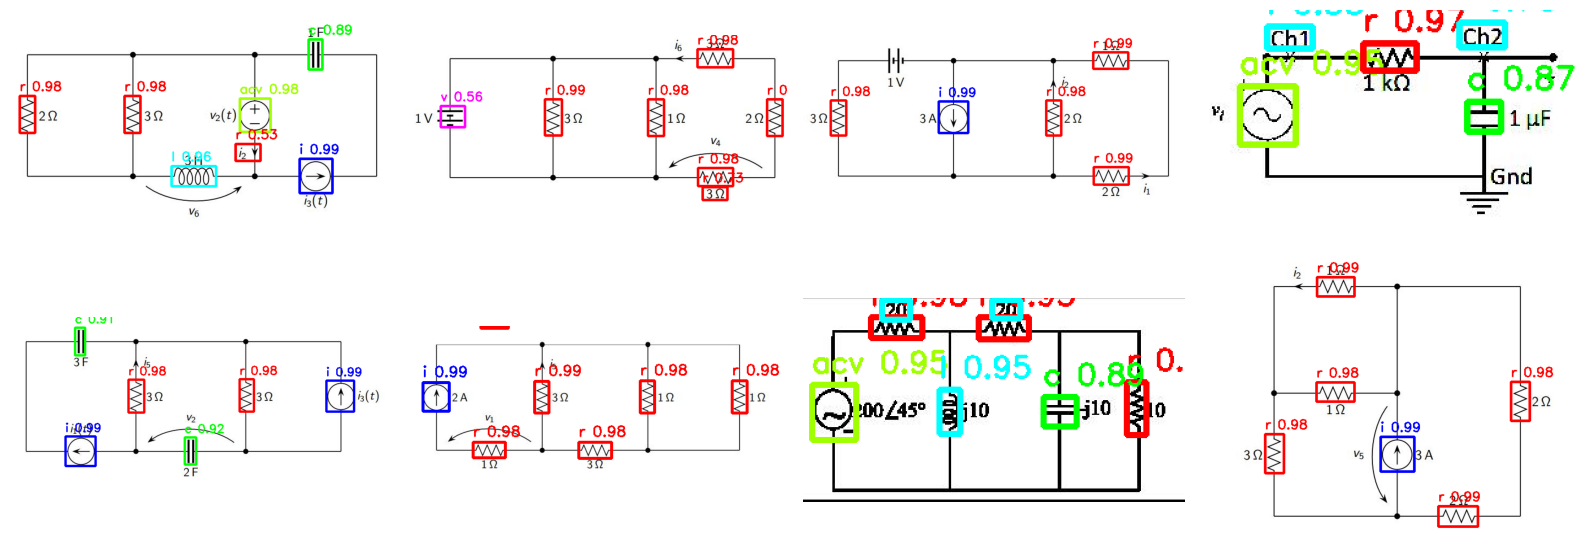

In [ ]:
CONF_THR = 0.5

# ---------------- CONFIG ----------------
val_dir = "datasets/CircuitRecognitioncoco/valid/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (576, 576))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) ) / 255
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    result_viz = visualize_results(img, outputs, threshold=CONF_THR)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(result_viz, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()